# Training Plots

Notebook for visualizing training curves from experiment metrics (compare/merge runs, optional best-epoch annotation).
Extend later with validation/test metrics, confusion matrix, etc.

Configure experiments root, experiment names, and output below.

## Config

Set experiments root, which runs to compare, merge behavior, and optional best-metric annotation.

In [1]:
import os
import sys
from pathlib import Path

# Ensure repo root is on path so "from utils.visualize_metrics" works when run from notebooks/
_repo_root = Path.cwd()
if (_repo_root / "utils").is_dir():
    pass
elif (_repo_root.parent / "utils").is_dir():
    _repo_root = _repo_root.parent
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

# Root folder containing experiment directories
EXPERIMENTS_ROOT = Path(os.environ.get("BRIDGE_EXPERIMENTS_ROOT", str(_repo_root / "experiments")))

# Experiment folder names to compare (e.g. two runs for merge)
EXPERIMENT_NAMES = [
    # "bridge-base-all-data-v0",
    # "bridge-base-all-data-v1", # resumed from v0 to 25 epochs w/ early stopping
    # "bridge-base-all-data-v2", # resumed from v0 to 50 epochs w/o early stopping
    "bridge-base-all-data-v3", # trained to 50 epochs w/o early stopping
    # "bridge-base-all-data-v4", # trained to 50 epochs w/o early stopping (voxel size 0.05)
]

# Version number per experiment (same length as EXPERIMENT_NAMES)
# VERSIONS = [0, 0]
VERSIONS = [0]

# When True and exactly two experiments, merge into one timeline (v0 epochs then v1 later epochs)
MERGE_RESUMED = False # set to True to merge v0 and v1; False to plot them separately or single run

# Output directory and filename
try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _nb_dir = os.getcwd()
if os.path.basename(_nb_dir) != "notebooks":
    _nb_dir = os.path.join(_nb_dir, "notebooks")
OUTPUT_DIR = Path(_nb_dir) / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FILENAME = "training_curves_v3.png"

# Validation metric to annotate with best epoch (e.g. "val_deck_iou" or "deck_iou"). Set to None to skip.
ANNOTATE_BEST_METRIC = "val_deck_iou"
# ANNOTATE_BEST_METRIC = None


## Merged training curves

Plot training curves from the configured experiments. Uses `utils.visualize_metrics.plot_metrics_compare`.

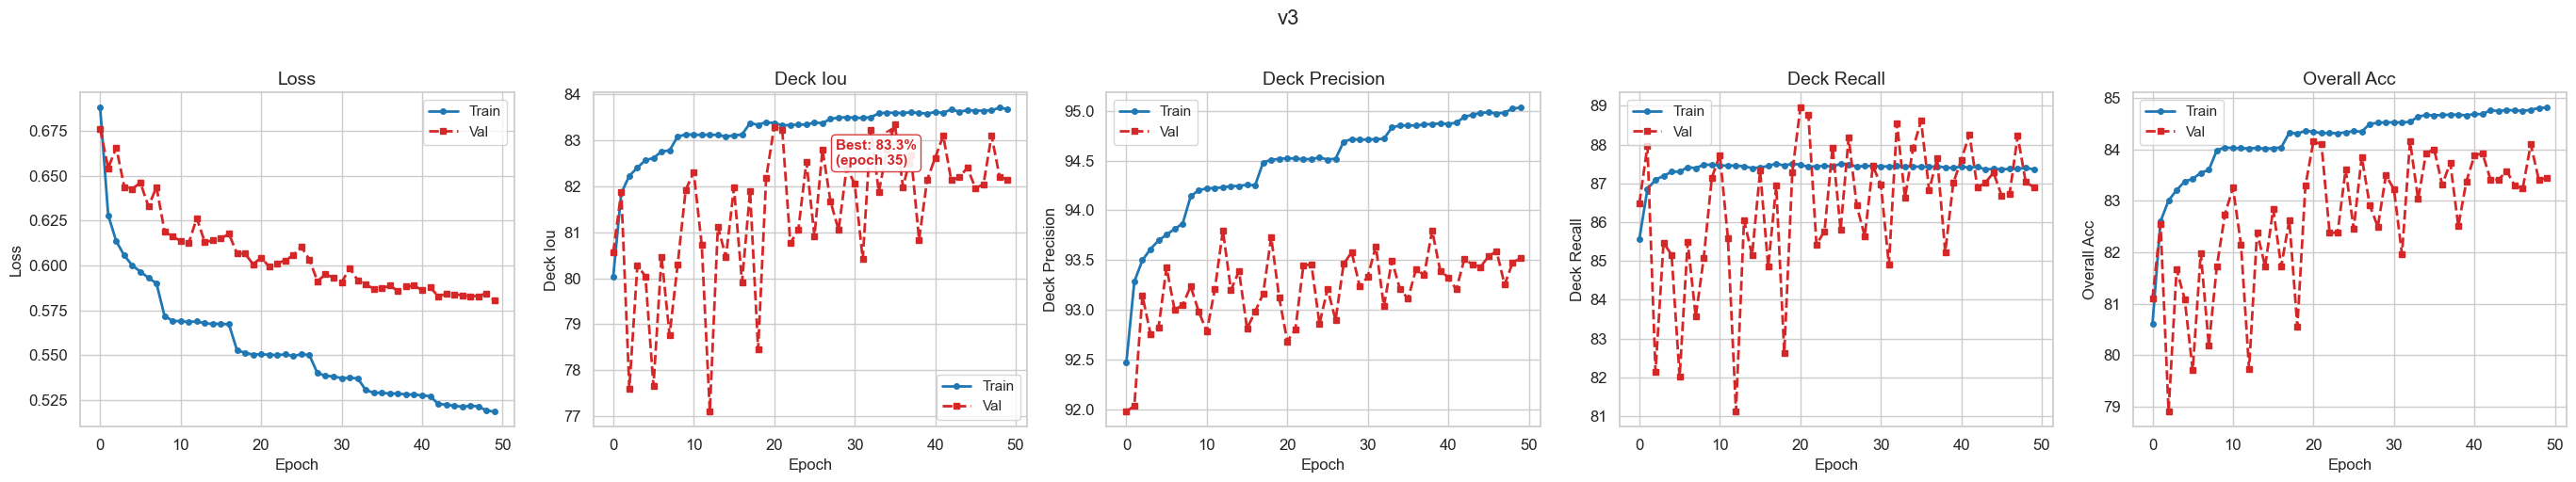

Comparison curves saved to: /Users/bbhandar/Work/ERT/git/bridge_classification/notebooks/outputs/training_curves_v3.png
Saved: /Users/bbhandar/Work/ERT/git/bridge_classification/notebooks/outputs/training_curves_v3.png


In [3]:
from utils.visualize_metrics import plot_metrics_compare

metrics_paths_with_labels = [
    (EXPERIMENTS_ROOT / exp / f"version_{v}" / "metrics.csv", exp)
    for exp, v in zip(EXPERIMENT_NAMES, VERSIONS)
]

missing = [p for p, _ in metrics_paths_with_labels if not p.exists()]
if missing:
    raise FileNotFoundError(f"Metrics files not found: {missing}")

out_path = OUTPUT_DIR / OUTPUT_FILENAME
plot_metrics_compare(
    metrics_paths_with_labels,
    out_path,
    merge_resumed=MERGE_RESUMED,
    annotate_best_metric=ANNOTATE_BEST_METRIC,
    show=True,
)
print(f"Saved: {out_path}")


## Training Results summary and progression table

**Summary:** Metrics at the **best epoch by Val Deck IoU** (same criterion as checkpoint selection)—use that checkpoint for inference.  
**Progression table:** Up to 5 epochs sampled across the full training run.

In [4]:
# Training Results summary and progression table (same data as the plot above)
import numpy as np
import pandas as pd

# Reuse same paths and merge logic as plot_metrics_compare
metrics_paths_with_labels = [
    (EXPERIMENTS_ROOT / exp / f"version_{v}" / "metrics.csv", exp)
    for exp, v in zip(EXPERIMENT_NAMES, VERSIONS)
]
epoch_dfs_with_labels = []
for csv_path, label in metrics_paths_with_labels:
    if not csv_path.exists():
        continue
    df = pd.read_csv(csv_path)
    epoch_df = df.groupby("epoch").max()
    epoch_dfs_with_labels.append((epoch_df, label))

if MERGE_RESUMED and len(epoch_dfs_with_labels) == 2:
    df0, label0 = epoch_dfs_with_labels[0]
    df1, label1 = epoch_dfs_with_labels[1]
    max_epoch_0 = df0.index.max()
    merged_df = pd.concat([
        df0[df0.index <= max_epoch_0],
        df1[df1.index > max_epoch_0],
    ]).sort_index()
    epoch_df = merged_df
else:
    epoch_df = epoch_dfs_with_labels[0][0] if epoch_dfs_with_labels else None

if epoch_df is None or epoch_df.empty:
    print("No metrics loaded.")
else:
    # Summary: all metrics at the single best epoch (by val_deck_iou), i.e. the checkpoint to use for inference
    train_iou_col = "train_deck_iou_epoch"
    val_iou_col = "val_deck_iou"
    val_loss_col = "val_loss"
    # Metrics are logged as 0-100 in train.py; only multiply by 100 if stored as ratio (0-1)
    def _pct(x):
        return x * 100 if x <= 1.0 else x

    if val_iou_col not in epoch_df.columns:
        best_epoch = None
    else:
        best_epoch = epoch_df[val_iou_col].idxmax()
    row = epoch_df.loc[best_epoch] if best_epoch is not None else None

    print("Training Results (summary at best epoch by Val Deck IoU — use this checkpoint for inference)")
    print("-" * 60)
    if row is not None:
        print(f"  Best epoch (by val_deck_iou): {int(best_epoch)}")
        if train_iou_col in epoch_df.columns:
            print(f"  Train Deck IoU:  {_pct(row[train_iou_col]):.1f}%")
        if val_iou_col in epoch_df.columns:
            print(f"  Val Deck IoU:    {_pct(row[val_iou_col]):.1f}%")
        if val_loss_col in epoch_df.columns:
            print(f"  Val Loss:        {row[val_loss_col]:.3f}")
        for label, col in [("Val Deck Precision", "val_deck_precision"), ("Val Deck Recall", "val_deck_recall"), ("Val Overall Acc", "val_overall_acc")]:
            if col in epoch_df.columns:
                print(f"  {label}: {_pct(row[col]):.1f}%")
    else:
        print("  No val_deck_iou column found.")
    print()

    # Progression table: up to 5 epochs spread across the full training run
    epochs_sorted = np.array(sorted(epoch_df.index.unique()))
    n_epochs = len(epochs_sorted)
    max_rows = 5
    if n_epochs <= max_rows:
        available = epochs_sorted.tolist()
    else:
        indices = np.round(np.linspace(0, n_epochs - 1, max_rows)).astype(int)
        available = list(dict.fromkeys(epochs_sorted[i] for i in indices))  # preserve order, no dupes

    cols = ["train_loss_epoch", "val_loss", "train_deck_iou_epoch", "val_deck_iou", "val_deck_precision", "val_deck_recall", "val_overall_acc"]
    col_map = {
        "train_loss_epoch": "Train Loss",
        "val_loss": "Val Loss",
        "train_deck_iou_epoch": "Train Deck IoU",
        "val_deck_iou": "Val Deck IoU",
        "val_deck_precision": "Val Deck Precision",
        "val_deck_recall": "Val Deck Recall",
        "val_overall_acc": "Val Overall Acc",
    }
    rows = []
    for e in available:
        row = {"Epoch": int(e)}
        for c in cols:
            if c in epoch_df.columns:
                v = epoch_df.loc[e, c]
                if "loss" in c:
                    row[col_map[c]] = f"{v:.3f}"
                else:
                    row[col_map[c]] = f"{_pct(v):.1f}%"
        rows.append(row)
    table_df = pd.DataFrame(rows)
    print("Training Progression (sampled epochs)")
    display(table_df)


Training Results (summary at best epoch by Val Deck IoU — use this checkpoint for inference)
------------------------------------------------------------
  Best epoch (by val_deck_iou): 20
  Train Deck IoU:  76.8%
  Val Deck IoU:    75.5%
  Val Loss:        0.849
  Val Deck Precision: 89.2%
  Val Deck Recall: 82.9%
  Val Overall Acc: 75.2%

Training Progression (sampled epochs)


,Epoch,Train Loss,Val Loss,Train Deck IoU,Val Deck IoU,Val Deck Precision,Val Deck Recall,Val Overall Acc
0,0,0.890,0.906,72.9%,67.5%,89.5%,73.3%,68.6%
1,12,0.780,0.861,76.4%,68.8%,90.8%,73.9%,70.4%
2,24,0.765,0.850,76.7%,73.0%,90.1%,79.2%,73.2%
3,37,0.746,0.837,77.1%,73.8%,90.2%,80.1%,73.9%
4,49,0.738,0.836,77.2%,73.6%,90.2%,79.9%,73.8%
